# Criterio di selezione per i picchi

In [1]:
from lib.readwav import readwav
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import ipywidgets as widgets
import os

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
available_files = [f for f in os.listdir('Data_organ') if f.endswith('.wav')]

available_files = sorted(available_files, key=lambda x: int(x.split("_")[1].split(".")[0]), reverse=False)

file_selector = widgets.Dropdown(
    options=available_files,
    description='Select file:',
)

display(file_selector)

Dropdown(description='Select file:', options=('note_1.wav', 'note_2.wav', 'note_3.wav', 'note_4.wav', 'note_5.…

In [4]:
num_periods_slider = widgets.IntSlider(value=5, min=1, max=200, step=1, description='Num Periods:')
display(num_periods_slider)

IntSlider(value=5, description='Num Periods:', max=200, min=1)

In [5]:
data = readwav(os.path.join('Data_organ', file_selector.value))

rate, data = data
channel1 = data[:,0]
channel2 = data[:,1]

In [6]:
n = np.arange(channel1.size)
N = len(channel1)


signal_peaks, _ = sp.signal.find_peaks(channel1[N//2-5000:N//2+5000], height=np.max(channel1)*0.1)
differences = np.diff(signal_peaks)
period = np.mean(differences) / rate

n_periods_in_window = num_periods_slider.value
window_size = int(n_periods_in_window * period * rate)
gaussian_window = np.exp(-0.5 * ((n - N/2) / (window_size/2))**2)


def apply_gaussian_window(signal, window_size, center):
    n = np.arange(len(signal))
    gaussian_window = np.exp(-0.5 * ((n - center) / (window_size/2))**2)
    return signal * gaussian_window


Estimated period: 0.0003 seconds
Number of peaks in filtered signal: 11


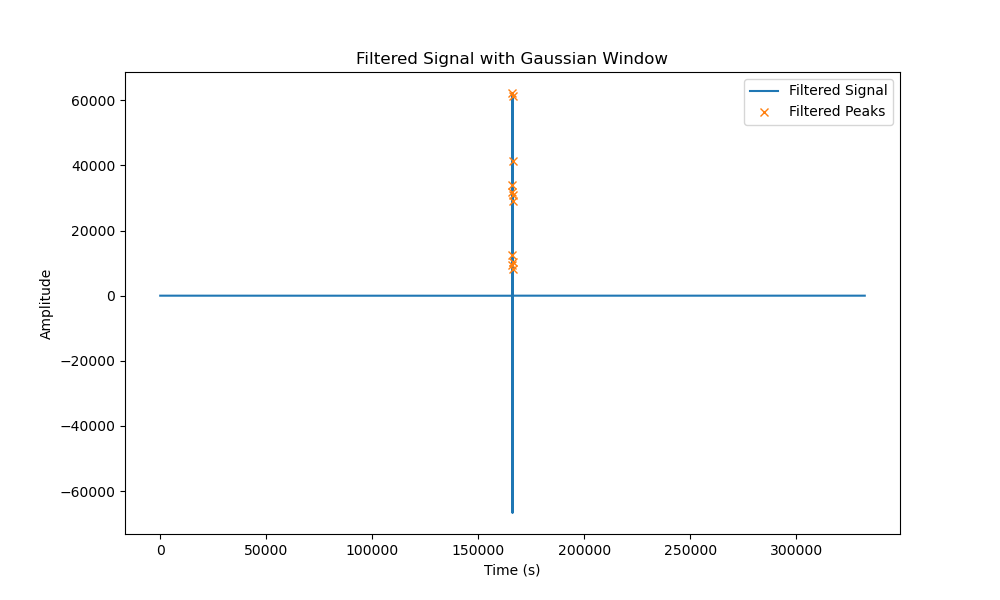

In [7]:
filtered_signal = np.multiply(np.asarray(channel1, dtype=float), gaussian_window)

filtered_peaks, _ = sp.signal.find_peaks(filtered_signal, height=np.max(filtered_signal)*0.1)

print(f"Estimated period: {period:.4f} seconds")
print(f"Number of peaks in filtered signal: {len(filtered_peaks)}")

plt.figure(figsize=(10, 6))
plt.plot(filtered_signal, label='Filtered Signal')
plt.plot(filtered_peaks, filtered_signal[filtered_peaks], "x", label='Filtered Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Filtered Signal with Gaussian Window')
plt.legend()
plt.show()

In [8]:
n_steps = len(range(1, channel1.shape[0], 1000))
freqs_channel1 = sp.fft.rfftfreq(len(channel1), 1/rate)
average_spectrum = np.zeros(len(freqs_channel1))

for i in range(1, channel1.shape[0], 1000):
    filtered_signal = apply_gaussian_window(channel1, window_size, i)
    fft_channel1 = sp.fft.rfft(filtered_signal)
    average_spectrum += np.abs(fft_channel1)**2

average_spectrum /= n_steps


In [9]:
log_freqs = np.log10(freqs_channel1[1:])  # Escludi la frequenza zero
log_spectrum = np.log10(average_spectrum[1:])  # Escludi la frequenza zero

peaks, _ = sp.signal.find_peaks(log_spectrum, prominence=0.9, distance=100)

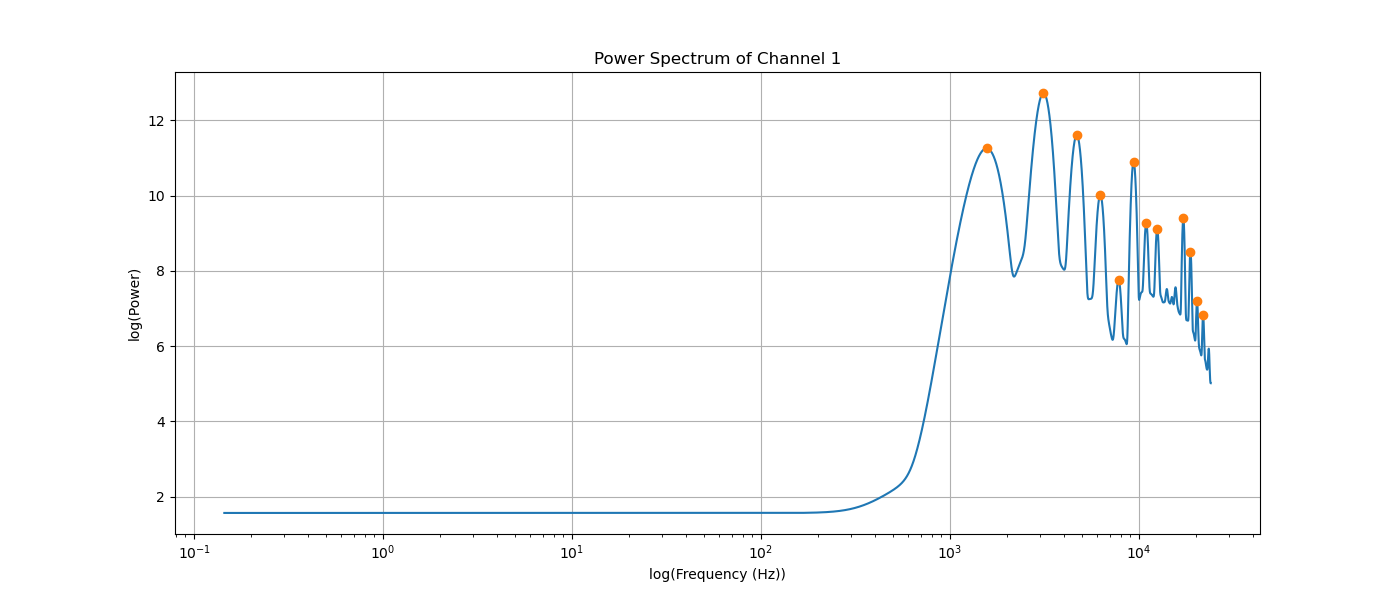

In [10]:
plt.figure(figsize=(14, 6))

freqs_channel1 = freqs_channel1[1:]  # Escludi la frequenza zero

plt.plot(freqs_channel1, log_spectrum, label='Log Power Spectrum')
plt.plot(freqs_channel1[peaks], log_spectrum[peaks], "o", label='Peaks (Fine)')

plt.xscale('log')

plt.xlabel('log(Frequency (Hz))')
plt.ylabel('log(Power)')
plt.title('Power Spectrum of Channel 1')
plt.grid()
plt.show()

In [11]:
first_n_peaks = peaks[:10]

# fit lineare per trovare la frequenza fondamentale
peak_freqs = log_freqs[first_n_peaks]
inds = np.arange(len(peak_freqs))
slope, intercept = np.polyfit(inds, peak_freqs, 1)

print(f"Estimated fundamental frequency: {10**intercept:.2f} Hz")

Estimated fundamental frequency: 2400.43 Hz


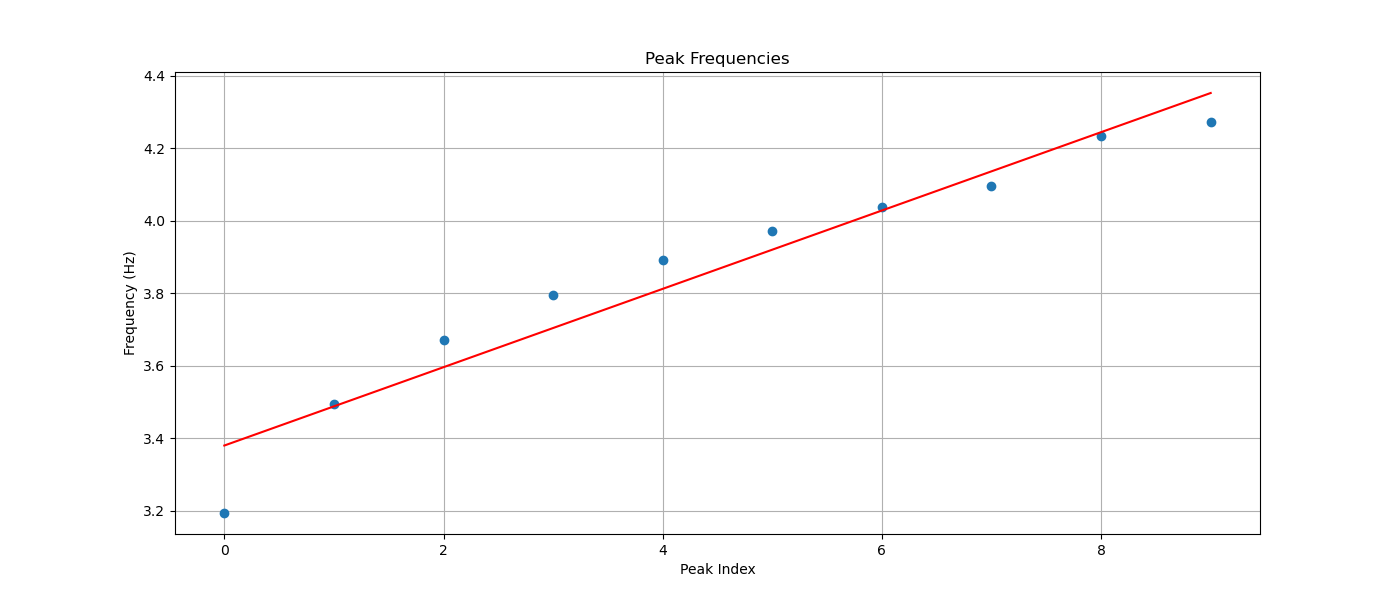

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(inds, peak_freqs, "o")

plt.plot(inds, slope*inds + intercept, label='Linear Fit', color='red')

plt.xlabel('Peak Index')
plt.ylabel('Frequency (Hz)')
plt.title('Peak Frequencies')
plt.grid()
plt.show()

In [13]:
def get_f0_from_gcd(freqs):
    fmin = np.min(freqs)
    fmax = np.max(freqs)
    candidates = np.arange(fmin/2, fmax, 0.1)

    best_f0 = None
    best_score = float('inf')

    for f0 in candidates:
        residual = np.sum(np.abs((freqs / f0) - np.round(freqs / f0)))
        if residual < best_score:
            best_score = residual
            best_f0 = f0
    
    return best_f0

estimated_f0 = get_f0_from_gcd(10**peak_freqs)
print(f"Estimated fundamental frequency (f0): {estimated_f0:.2f} Hz")

Estimated fundamental frequency (f0): 1563.39 Hz


### Fondamentale da bayes

Possiamo scrivere una likelyhood per i picchi, dividendola in due casi: quando il picco è reale e quando è un falso positivo. Possiamo quindi scrivere la probabilità di osservare un picco a $f=f_k$ come:

$$f_k\sim q\cdot\mathcal{N}(n_kf_0, \sigma^2) + (1-q)\cdot\mathcal{U}$$

dove $q$ è la probabilità di aver beccato un picco reale, $n_k$ è l'indice del picco e $f_0$ è la frequenza fondamentale e $\sigma^2$ è l'incertezza. L'idea è che se è un picco reale, allora sarà vicino a un multiplo della fondamentale con una certa incertezza, mentre se è un falso positivo, allora sarà distribuito uniformemente.

Non conosciamo gli $n_k$, ma possiamo marginalizzare:
$$P(f_k|f_0, q, \sigma^2) = \sum_{n=1}^N P(f_k|f_0, q, \sigma^2, n) = q\cdot\sum_{n=1}^N P(n)\cdot\mathcal{N}(nf_0, \sigma^2) + (1-q)\cdot\mathcal{U}$$

Abbiamo alla peggio 20 picchi, quindi pochi termini per la somma.

A questo punto possiamo scrivere la log-likelihood per tutti i picchi:
$$\mathcal{L}(f_0, q, \sigma^2) = \sum_{k=1}^K \log P(f_k|f_0, q, \sigma^2)=\sum_{k=1}^K \log\left(q\cdot\sum_{n=1}^N P(n)\cdot\mathcal{N}(nf_0, \sigma^2) + (1-q)\cdot\mathcal{U}\right)$$

Il prior su $n$ possiamo prenderlo uniforme tra 1 e 20, quindi $P(n)=\frac{1}{20}$, oppure possiamo restringere il suo intervallo a $floor(f_k/f_0)-1$ e $floor(f_k/f_0)+1$ o qualcosa di questo tipo. Gli altri saranno i soliti uniformi su qualche intervallo ragionevole.

Possiamo usare emcee per campionare e trovarci la $f_0$ e il suo errore. 

In [14]:
import emcee

observed_freqs = np.asarray(freqs_channel1[peaks], dtype=float)

# Limiti prior
f_min = np.min(observed_freqs) / 2.0
f_max = np.min(observed_freqs) * 1.2

log_sigma_min = np.log(0.1)   # 0.1 Hz
log_sigma_max = np.log(10)   # 10 Hz

n_max = 20
ns = np.arange(1, n_max + 1, dtype=float)

# Costanti utili
log_norm_const = -0.5 * np.log(2.0 * np.pi)
log_uniform = -np.log(f_max - f_min)

def log_prob_vect(theta_batch):
    theta_batch = np.atleast_2d(theta_batch)

    f0 = theta_batch[:, 0]
    log_sigma = theta_batch[:, 1]
    q = theta_batch[:, 2]

    logp = np.full(theta_batch.shape[0], -np.inf, dtype=float)

    valid = (
        (f0 > f_min) & (f0 < f_max) &
        (log_sigma > log_sigma_min) & (log_sigma < log_sigma_max) &
        (q > 0.0) & (q < 1.0)
    )

    if not np.any(valid):
        return logp

    f0v = f0[valid]
    log_sigmav = log_sigma[valid]
    qv = q[valid]

    sigma = np.exp(log_sigmav)

    # expected shape: (Wv, N)
    expected = f0v[:, None] * ns[None, :]

    # residuals shape: (Wv, K, N)
    residuals = observed_freqs[None, :, None] - expected[:, None, :]

    # log N(f_k | n f0, sigma^2), shape: (Wv, K, N)
    log_gauss = (
        -0.5 * (residuals / sigma[:, None, None]) ** 2
        - np.log(sigma)[:, None, None]
        + log_norm_const
    )

    # log media su n: log(1/N * sum_n ...)
    log_harm = sp.special.logsumexp(log_gauss, axis=2) - np.log(n_max)  # (Wv, K)

    # miscela q * harmonic + (1-q) * uniforme in log-space
    log_mix = np.logaddexp(
        np.log(qv)[:, None] + log_harm,
        np.log1p(-qv)[:, None] + log_uniform
    )  # (Wv, K)

    logp[valid] = np.sum(log_mix, axis=1)
    return logp

# Inizializzazione walker
ndim, nwalkers = 3, 50

f0_guess = np.min(observed_freqs)
sigma_guess = 10.0  # Hz

p0 = np.column_stack([
    np.random.normal(f0_guess, f0_guess * 0.8, nwalkers),
    np.random.normal(np.log(sigma_guess), 0.5, nwalkers),
    np.random.uniform(0.5, 1.0, nwalkers)
])

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_prob_vect,
    vectorize=True,
)

state = sampler.run_mcmc(p0, 100000, progress=True)


  0%|          | 0/100000 [00:00<?, ?it/s]/home/ele/anaconda3/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 100000/100000 [00:35<00:00, 2849.96it/s]


In [15]:
tau = sampler.get_autocorr_time(quiet=True)
print(f"Autocorrelation time: {tau}.\nLunghezza catena: {sampler.get_chain().shape[0]}.\nRapporto catena/autocorr_time: {sampler.get_chain().shape[0] / tau}.")

/home/ele/anaconda3/lib/python3.13/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]
The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 2000;
tau: [         nan 12528.585196          nan]


Autocorrelation time: [         nan 12528.585196          nan].
Lunghezza catena: 100000.
Rapporto catena/autocorr_time: [       nan 7.98174722        nan].


In [16]:
import corner

discard = int(2 * np.max(tau))
thin = int(0.5 * np.min(tau))

samples = sampler.get_chain(discard=discard, thin=thin, flat=True)
fig = corner.corner(samples, labels=["f0", "log_sigma", "q"], truths=[estimated_f0, None, None])
plt.show()

ValueError: cannot convert float NaN to integer

In [ ]:
best_f0_mcmc = np.median(samples[:, 0])
f0_95 = np.percentile(samples[:, 0], 95)
print(f"Estimated f0 (MCMC): {best_f0_mcmc:.2f} Hz")
print(f"95% credible interval for f0: [{np.percentile(samples[:, 0], 2.5):.2f}, {f0_95:.2f}] Hz")

In [ ]:
print("Picchi osservati:", observed_freqs)
print("Range f0 sensato:", observed_freqs.min() / 20, "->", observed_freqs.min())
print("Spaziatura media:", np.diff(np.sort(observed_freqs)).mean())